In [1]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from dotenv import load_dotenv
import os
from ollama import Client

load_dotenv()

True

In [2]:
from openai import OpenAI
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [4]:
class State(TypedDict):
    topic: str
    advertisement: str
    review: str
    tagline: str
    combined_output: str


In [5]:
def generate_advertisement(state: State) -> State:
    """Calls OpenAI API to generate an advertisement related to the given topic."""
    msg = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a creative AI that writes catchy advertisements."},
            {"role": "user", "content": f"Write a catchy advertisement for a product related to {state['topic']}."}
        ],
        max_tokens=200
    )
    advertisement = msg.choices[0].message.content.strip()
    return {"advertisement": advertisement}

In [6]:
# Step 4: Generate a product review
def generate_review(state: State):
    """Calls OpenAI API to generate a detailed product review for the given topic."""
    msg = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that writes detailed product reviews."},
            {"role": "user", "content": f"Write a product review for a product related to {state['topic']}. Include pros and cons."}
        ],
        max_tokens=300
    )
    review = msg.choices[0].message.content.strip()
    return {"review": review}

In [7]:
# Step 5: Generate a catchy tagline
def generate_tagline(state: State):
    """Calls OpenAI API to generate a catchy tagline for the given topic."""
    msg = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a creative AI that generates catchy taglines."},
            {"role": "user", "content": f"Create a short, catchy tagline for a product related to {state['topic']}."}
        ],
        max_tokens=50
    )
    tagline = msg.choices[0].message.content.strip()
    return {"tagline": tagline}


In [8]:
def combine_outputs(state: State):
    """Combines advertisement, review, and tagline into a single output."""
    combined = (
        f"Advertisement:\n{state['advertisement']}\n\n"
        f"Review:\n{state['review']}\n\n"
        f"Tagline:\n{state['tagline']}"
    )
    return {"combined_output": combined}

In [9]:
def build_workflow():
    "construct and compile the langraph parallel workflow"
    parallel_builder = StateGraph(State)
    parallel_builder.add_node("generate_advertisement", generate_advertisement)
    parallel_builder.add_node("generate_review", generate_review)
    parallel_builder.add_node("generate_tagline", generate_tagline)
    parallel_builder.add_node("combine_output", combine_outputs)

    parallel_builder.add_edge(START, "generate_advertisement")
    parallel_builder.add_edge(START, "generate_review")
    parallel_builder.add_edge(START, "generate_tagline")
    parallel_builder.add_edge("generate_advertisement", "combine_output")
    parallel_builder.add_edge("generate_review", "combine_output")
    parallel_builder.add_edge("generate_tagline", "combine_output")
    parallel_builder.add_edge("combine_output", END)

    parallel_workflow = parallel_builder.compile()
    return parallel_workflow









In [10]:
topic = "smart home devices"
parallel_workflow = build_workflow()
state = parallel_workflow.invoke({"topic": topic})
result = parallel_workflow.invoke(state)

In [11]:
result

{'topic': 'smart home devices',
 'advertisement': '🌟 Transform Your Home into a Smart Haven with HomeGenius! 🌟\n\n✨ Imagine a life where your home knows you better than you know yourself! With HomeGenius, turn your ordinary space into an extraordinary smart home. \n\n🚪 **Smart Locks** that secure your sanctuary, 🛋️ **Smart Lighting** that sets the mood just right, and 🎶 **Smart Speakers** that fill your space with sound as unique as your taste!\n\n📱 Control everything with a simple tap or your voice! From adjusting the thermostat while lounging on the couch to scheduling your coffee maker to brew at dawn, HomeGenius makes every moment magical. \n\n🔒 **Safe, Reliable, and User-Friendly** – Making your life seamless, one gadget at a time.\n\n🔥 **LIMITED TIME OFFER**! Order now and get 20% off your first purchase plus FREE installation on select devices! \n\n🌐 Visit us at www.homegenius.com and take the first step towards a',
 'review': '**Product Review: Philips Hue White and Color Ambia

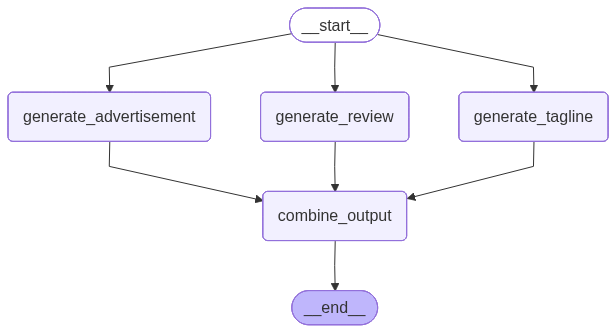

In [12]:

from IPython.display import Image, display

try:
    display(Image(parallel_workflow.get_graph().draw_mermaid_png()))
except Exception as e:

    print(e)